Code for generating 2 agent simulations where goal directions are orthogonal (figure 9); for RSFM (rotational SFM)
setup periodic in x and y, but y limits are very large so it's practically unbounded in y

# FSM

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist
from matplotlib.animation import FuncAnimation
import matplotlib.patches as patches
from math import cos, sin, pi
from IPython.display import HTML, Video, display

"""
-----------------------
Helper Functions: Later move it to another file.py
-----------------------

"""
def selfPropulsionForce(m, tau, desiredSpeed, desiredDirection, velocity):
    desiredDirection=np.arctan2(desiredDirection[:,1],desiredDirection[:,0])

    speed=((velocity**2).sum(axis=1))**0.5
    angle=np.arctan2(velocity[:,1],velocity[:,0])
    desiredSpeed=desiredSpeed.ravel()
    ds_dt=(desiredSpeed-speed)*(m/tau)
    dphi_dt=np.arctan2(np.sin(desiredDirection-angle),np.cos(desiredDirection-angle))/(0.5*tau*m)
    outforce=np.zeros_like(velocity)
    outforce[:,0]=ds_dt*np.cos(angle)+dphi_dt*(-speed*np.sin(angle))
    outforce[:,1]=ds_dt*np.sin(angle)+dphi_dt*(speed*np.cos(angle))
    return outforce

def interactionForce(position, R, A, B, Lx, Ly):
    N = position.shape[0]
    epsilon = 1e-6 # Used to avoid infinity
    agent_size = 2 * R

    x = position[:, 0].reshape(-1, 1)
    y = position[:, 1].reshape(-1, 1)

    dx = x - x.T
    dy = y - y.T


    dx_u = dx - np.round(dx / Lx) * Lx
    dy_u = dy - np.round(dy / Ly) * Ly

    # Euclidean distance calculation
    dist = np.sqrt(dx_u**2 + dy_u**2)
    
    valid_index = (dist < (3*R)) & (dist > 0)

    # Unit vectors
    dij_x = np.zeros_like(dist)
    dij_y = np.zeros_like(dist)
    np.divide(dx_u, dist, out=dij_x, where=dist>epsilon)
    np.divide(dy_u, dist, out=dij_y, where=dist>epsilon)   
    # np.divide(dx_u, dist+epsilon, out=dij_x)#, where=dist>epsilon)
    # np.divide(dy_u, dist+epsilon, out=dij_y)#, where=dist>epsilon)
    
    # Apply valid_index mask
    dij_x[~valid_index] = 0
    dij_y[~valid_index] = 0
    
    # Effective distance
    effective_dist = np.maximum(dist - agent_size, epsilon)
    
    # Force magnitude calculation
    force_magnitude = np.zeros_like(dist)
    np.power(effective_dist, -B, out=force_magnitude, where=effective_dist>epsilon)
    force_magnitude *= -A
    
    force_magnitude[~valid_index] = 0

    interaction_force = np.column_stack((np.sum(force_magnitude * dij_x, axis=0),np.sum(force_magnitude * dij_y, axis=0)))

    return interaction_force


In [51]:
# Imports and Initializations
import numpy as np
import matplotlib.pyplot as plt

from parfor import parfor
import csv
from tqdm import tqdm

In [52]:
# Setting model parameters


def periodify(pos,Lx,Ly):
    if len(pos.shape)==1:
        pos[0]=pos[0]%Lx
        pos[1]=pos[1]%Ly
    else:
        pos[:,0]=pos[:,0]%Lx
        pos[:,1]=pos[:,1]%Ly
    return pos



def getdisp(a,b):
    disp=a-b
    if len(disp.shape)==1:
        disp[0]=disp[0]-np.round(disp[0]/Lx)*Lx
        disp[1]=disp[1]-np.round(disp[1]/Ly)*Ly
    else:
        disp[:,0]=disp[:,0]-np.round(disp[:,0]/Lx)*Lx
        disp[:,1]=disp[:,1]-np.round(disp[:,1]/Ly)*Ly
    return disp





# Parallel

In [53]:
from tqdm import tqdm
import pickle


deltaT = 0.005
timeStep = 35000
totalTime = deltaT*timeStep




N=2
Lx=20
Ly=500
R = 1
m = 1
A = 0.01
B = 3
tau = 1


updateT=tau
updateF=round(updateT/deltaT)



Nr = 1/2
deltheta=np.pi/8
numagents=N
tau_fut=6
agentradius=R

numsamp=50





# number of agent in each group
g1 = int(round(N * Nr))
# g1=1
g2 = N - g1


In [54]:
# Initial Position
# columns=9
for rep in range(15):
    xData = []
    yData = []
    uData = []
    vData = []
    desdirs=[]
    forces=[]


    # N=columns*10
    # Lx=columns*5
    # numagents=N
    # g1 = int(round(N * Nr))
    # g2 = N - g1
    
    
    # position=np.array(sum([[[x,y] for y in [1.9,5.7,9.5,13.3,17.1]] for x in [2,4.5,7,9.5,12,14.5,17,19.5]],[]))#[np.random.permutation(np.arange(N))]
    # position=np.array(sum([[[x,y] for y in [1.5,5.5,9.5,13.5,17.5]] for x in [2,4.5,7,9.5,12,14.5,17,19.5]],[]))[np.random.permutation(np.arange(N))]

    # position=np.array(sum([[[x,y] for y in [1.5,5.5,9.5,13.5,17.5]] for x in np.arange(2,Lx,2.5)],[]))#[np.random.permutation(np.arange(N))]
    # position[g1:,0]=position[g1:,0]+5
    # Lx+=5
    
    # position=np.array(sum([[[x,y] for y in [1.25,3.75,6.25,8.75,11.25,13.75,16.25,18.75]] for x in [2,4.5,7,9.5,12,14.5,17,19.5]],[]))#[np.random.permutation(np.arange(N))]
    position=np.array([[4,250],[16,250]])
    # position=np.array([[4,250],[16,250],[4,262],[16,262]])
    # position=np.array([[4.5,9.5]]+sum([[[x,y] for y in [1.5,5.5,9.5,13.5,17.5]] for x in [12,14.5,17,19.5]],[]))
    # position=np.array([[3,10]]+list(np.random.random(size=(5,2))*18)+[[17,10]])
    # position=startpos.copy()[np.random.permutation(np.arange(90))]
    position=position+(np.random.random(size=position.shape)-0.5)*0.001
    position[:,0]=position[:,0]%Lx
    position[:,1]=position[:,1]%Ly



    # Initial Speed
    # speed = np.array([1,1]).reshape(-1,1)
    speed=0.1
    
    # Initial Direction
    # theta = np.random.uniform(0, 2* np.pi, size = (N, 1))
    # theta=np.array([0,np.pi/2]).reshape(-1,1)
    # theta = np.ones(shape=(N,1))*np.pi/2
    # print(theta)
    # Parameter for force calculation
    theta=np.array([[np.pi/4],[3*np.pi/4]])
    # theta=np.array([[np.pi/4],[3*np.pi/4],[-np.pi/4],[-3*np.pi/4]])
    velocity = speed * np.column_stack((np.cos(theta), np.sin(theta)))
    
    # Inital velocity

    
    # Desired speed
    desiredSpeed = np.ones((N,1)) * 1
    # desiredSpeed[:g1] = 0
    
    
    # Desired direction
    desiredDirectionA = np.ones((N, 1))
    # desiredDirectionA[:g1] = np.pi/4
    # desiredDirectionA[g1:] = 3*np.pi/4
    desiredDirectionA=theta.copy()
    desired=(desiredDirectionA.copy()).ravel()
    desiredDirection = np.hstack((np.cos(desiredDirectionA), np.sin(desiredDirectionA)))

    # ############################################################

    # file=glob('./40agents_nofsm/*_11_*.pickle')[0]
    # with open(file,'rb') as f:
    #     alldat=pickle.load(f)
    #     position=np.vstack([alldat['xData'][0],alldat['yData'][0]]).T
    #     velocity=np.vstack([alldat['uData'][0],alldat['vData'][0]]).T

    # ############################################################
    
    xData.append(position[:,0])
    yData.append(position[:,1])
    
    uData.append(velocity[:,0])
    vData.append(velocity[:,1])
    
    
    
    
    
    for t in tqdm(range(timeStep)):
        desdirs.append(desiredDirection[:].copy())
      # Force calculation
        f1 = selfPropulsionForce(m, tau, desiredSpeed, desiredDirection, velocity)#*np.random.normal(0,1,size=(N,2))
        f2 = interactionForce(position, R, A, B, Lx,Ly)
        force = (f1+f2)/m

        newPosition = position + (velocity * deltaT) + (0.5 * force * deltaT**2)
        newPosition[:,0] = (newPosition[:,0]) % Lx
        newPosition[:,1] = (newPosition[:,1]) % Ly
    

        deltaV = force * deltaT
    
        vint = velocity + deltaV
    
        f1_new = selfPropulsionForce(m, tau, desiredSpeed, desiredDirection, vint) 
        f2_new =  interactionForce(newPosition, R, A, B, Lx,Ly)
        
        forceNew = (f1_new + f2_new)/m
        
        newVelocity = velocity + (0.5 * (force + forceNew)) * deltaT
    
        velocity = newVelocity
        position = newPosition
        

        xData.append(newPosition[:,0])
        yData.append(newPosition[:,1])
        
        uData.append(newVelocity[:,0])
        vData.append(newVelocity[:,1])
        forces.append([f1,f2])

    with open('./2agents_nofsm_nematic_ortho/2_agents_nofsm_nematic_ortho_'+str(rep)+'_'+str(np.random.randint(10000))+'.pickle','wb') as file:
        pickle.dump({'xData':xData,'yData':yData,'uData':uData,'vData':vData,'forces':forces,'desdirs':desdirs,'Lx':Lx,'Ly':Ly,'note':'agents have orthogonal desired directions'},file)#,'note':'tried to incorporate neighbor effects while predicting motion of other agents'},file)



100%|██████████████████████████████████████████████████████████████████████████| 35000/35000 [00:07<00:00, 4662.65it/s]


In [ ]:
# import pickle
# with open('sdfsaDFaf_40_agents_withfsm','wb') as file:
#     pickle.dump({'xData':xData,'yData':yData,'uData':uData,'vData':vData,'forces':forces,'desdirs':desdirs},file)#,'note':'tried to incorporate neighbor effects while predicting motion of other agents'},file)

# alldata={'xData':xData,'yData':yData,'uData':uData,'vData':vData,'forces':forces,'desdirs':desdirs,'note':'tried to incorporate neighbor effects while predicting motion of other agents'}

# plots

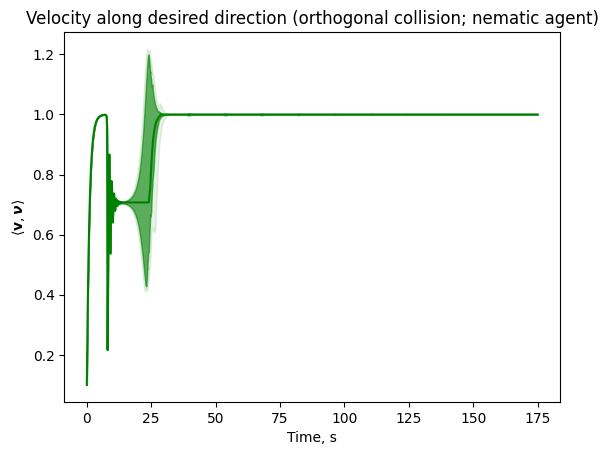

In [71]:
# Ploting velocity data
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype']='none'
from glob import glob
filestart='./2agents_nofsm_nematic_ortho/*.pickle'
files=glob(filestart)
uData_all=[]
vData_all=[]
for file in files:
    with open(file,'rb') as f:
        alldata=pickle.load(f)
        uData_all.append(alldata['uData'])
        vData_all.append(alldata['vData'])

veldata=np.array([uData_all,vData_all])

op=np.einsum('irta,ai->rta',veldata,desiredDirection)
op=np.transpose(op,axes=(0,2,1)).reshape(30,35001).T

op_mean = op.mean(axis=1)
op_median = np.quantile(op,0.5,axis=1)
op_lq = np.quantile(op,0.25,axis=1)
op_uq = np.quantile(op,0.75,axis=1)
op_min = np.quantile(op,0.1,axis=1)
op_max = np.quantile(op,0.9,axis=1)



t = np.arange(0, totalTime, deltaT)
t=np.arange(35001)*deltaT

plt.figure()
plt.plot(t,op_median, label = 'Group 1 [right]',color='green')
plt.fill_between(t,op_lq,op_uq,alpha=0.6,color='green')
plt.fill_between(t,op_min,op_max,alpha=0.1,color='green')

# plt.ylim(-1.05,1.05)
# plt.xlim([0, 10])
plt.title('Velocity along desired direction (orthogonal collision; nematic agent)')
plt.xlabel('Time, s')
plt.ylabel('$\\left<\\mathbf{v},\\boldsymbol{\\nu}\\right>$')

plt.savefig('./results_2agents_nematic_ortho.svg',facecolor='white',bbox_inches='tight')
# plt.axvline(13)
# plt.legend()

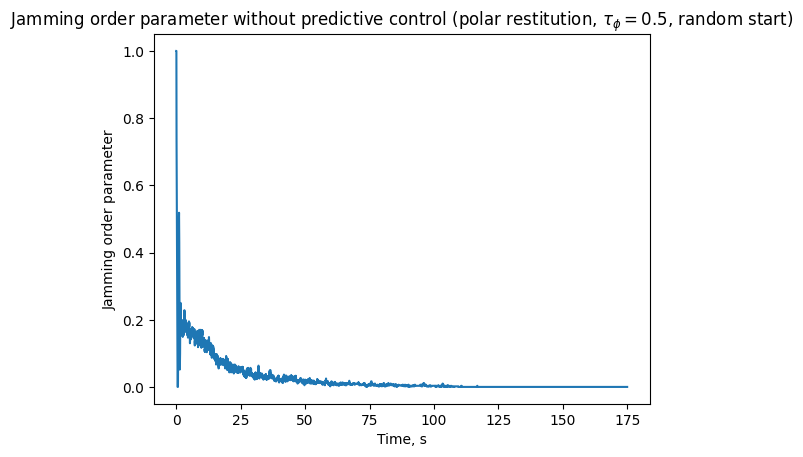

In [10]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype']='none'
g1=20
uvel_g1=np.array(uData_all).reshape(15,35001,40).T[:g1]
uvel_g1=uvel_g1.transpose(0,2,1)
uvel_g1=uvel_g1.reshape(-1, uvel_g1.shape[-1]).T

uvel_g2=np.array(uData_all).reshape(15,35001,40).T[g1:]
uvel_g2=uvel_g2.transpose(0,2,1)
uvel_g2=uvel_g2.reshape(-1, uvel_g2.shape[-1]).T

num_g1=(uvel_g1<0.15).sum(axis=1)
num_g2=(uvel_g2>-0.15).sum(axis=1)
jam_op=(num_g1+num_g2)/(40*15)
plt.plot(t,jam_op)

plt.xlabel('Time, s')
plt.ylabel('Jamming order parameter')
plt.title('Jamming order parameter without predictive control (polar restitution, $\\tau_{\\phi}=0.5$, random start)')
plt.savefig('./sdf_results_40agents/jam_op_nofsm_nematic_halftauphi_random_start.svg',facecolor='white',bbox_inches='tight')

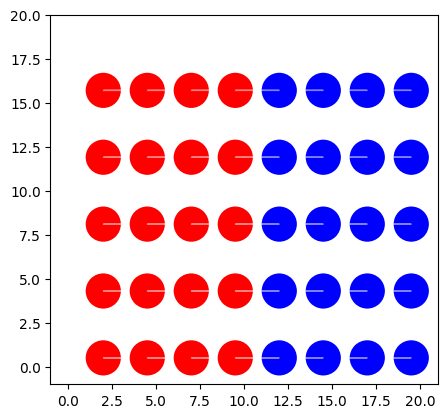

In [37]:
# xData=np.array(xData).T
# xData=np.array(xData).T
for i in range(1):
# for i in (14*200,14*200+1):
    plt.figure()
    for ag in range(N):
        xpos=(xData[i][ag])
        ypos=((yData[i][ag])+10)%19
        vx=uData[i][ag]
        vy=vData[i][ag]
        desx=desdirs[i][ag,0]
        desy=desdirs[i][ag,1]
        # dir=cmath.rect(1,dirdata[t,ag])
        plt.gca().add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue'))
        plt.arrow(xpos,ypos,vx,vy)
        plt.arrow(xpos,ypos,desx,desy,color='white',alpha=0.5)
        # plt.arrow(xpos,ypos,np.real(dir),np.imag(dir))
    plt.xlim(-1,Lx+1)
    plt.ylim(-1,Ly+1)
    plt.gca().set_aspect(1)

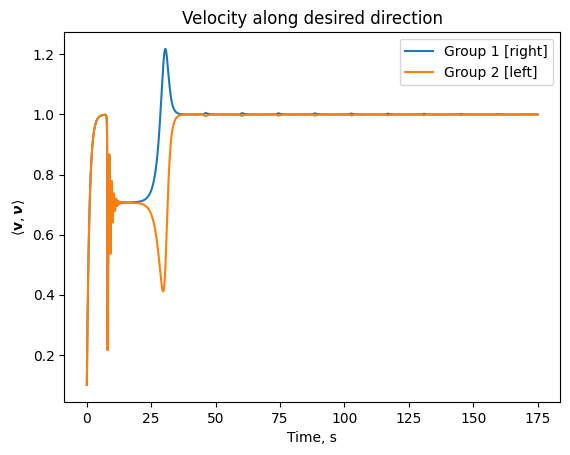

In [49]:
veldata=np.array([uData,vData])
op=np.einsum('ita,ai->at',veldata,desiredDirection)
plt.plot(t,op[0][:-1], label = 'Group 1 [right]')
plt.plot(t,op[1][:-1], label = 'Group 2 [left]')
# plt.plot(op[2])
# plt.plot(op[3])
# plt.xlim(0,5000)
plt.xlabel('Time, s')
plt.ylabel('$\\left<\\mathbf{v},\\boldsymbol{\\nu}\\right>$')
plt.title('Velocity along desired direction')
plt.legend()

(35001, 2)


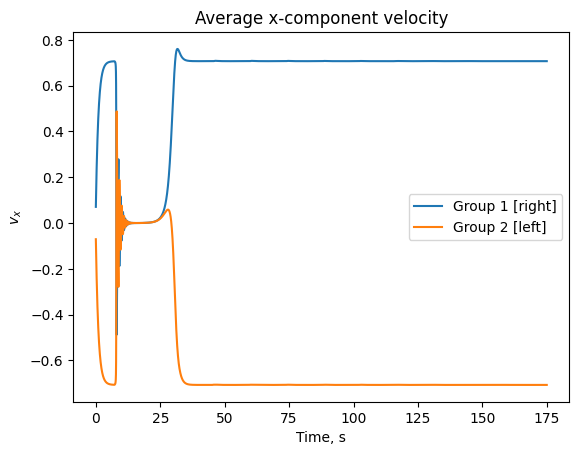

In [48]:

# import numpy as np
# import matplotlib.pyplot as plt
# plt.rcParams['svg.fonttype']='none'
# from glob import glob
# filestart='./40agents_nofsm/*.pickle'
# files=glob(filestart)
# for file in files:
#     with open(file,'rb') as f:
#         uData=pickle.load(f)['uData']
#     plt.figure()
#     print(file)
    
uData_p = np.array(uData)
# vData_p = np.array(vData)
print(uData_p.shape)
order_g1 = np.mean(uData_p[:, :g1], axis = 1)
order_g2 = np.mean(uData_p[:, g1:], axis = 1)
t = np.arange(0, totalTime, deltaT)


# plt.figure()
plt.plot(t, order_g1[:-1], label = 'Group 1 [right]')
plt.plot(t, order_g2[:-1], label = 'Group 2 [left]')
# plt.xlim([0, 10])
# plt.title(file)
plt.title('Average x-component velocity')
plt.xlabel('Time, s')
plt.ylabel(r'$v_{x}$')
# plt.xscale('log')
# plt.axvline(13)
plt.legend()

In [52]:
# file=glob('./40agents_nofsm/*_5_*.pickle')[0]
# with open(file,'rb') as f:
#     alldat=pickle.load(f)
#     position=np.vstack([alldat['xData'][0],alldat['yData'][0]]).T
#     velocity=np.vstack([alldat['uData'][0],alldat['vData'][0]]).T

In [40]:

filename='./images/nematic_4_failure'
for i in range(0,timeStep,125):
# for i in (14*200,14*200+1):
    plt.figure()
    for ag in range(N):
        xpos=(xData[i][ag])
        ypos=(yData[i][ag])
        vx=uData[i][ag]
        vy=vData[i][ag]
        desx=desdirs[i][ag,0]
        desy=desdirs[i][ag,1]
        # dir=cmath.rect(1,dirdata[t,ag])
        plt.gca().add_patch(plt.Circle((xpos,ypos),1,fc='red' if ag<g1 else 'blue'))
        plt.arrow(xpos,ypos,vx,vy)
        plt.arrow(xpos,ypos,desx,desy,color='white',alpha=0.5)
        # plt.arrow(xpos,ypos,np.real(dir),np.imag(dir))
    plt.xlim(-1,Lx+1)
    plt.ylim(200,295)
    # plt.axhline(0)
    # plt.axhline(Ly)
    plt.gca().set_aspect(1)
    plt.savefig(filename+'_prop_'+str(i)+'.png',facecolor='white')
    plt.close()

./40agents_nofsm\40_agents_nofsm_0_309.pickle
(35001, 40)
./40agents_nofsm\40_agents_nofsm_10_9975.pickle
(35001, 40)
./40agents_nofsm\40_agents_nofsm_11_5350.pickle
(35001, 40)
./40agents_nofsm\40_agents_nofsm_12_2411.pickle
(35001, 40)
./40agents_nofsm\40_agents_nofsm_13_856.pickle
(35001, 40)
./40agents_nofsm\40_agents_nofsm_14_1000.pickle
(35001, 40)
./40agents_nofsm\40_agents_nofsm_1_2838.pickle
(35001, 40)
./40agents_nofsm\40_agents_nofsm_2_4319.pickle
(35001, 40)
./40agents_nofsm\40_agents_nofsm_3_3817.pickle
(35001, 40)
./40agents_nofsm\40_agents_nofsm_4_9760.pickle
(35001, 40)


C:\Users\BalaGopal\AppData\Local\Temp\ipykernel_32692\183581778.py:10: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


./40agents_nofsm\40_agents_nofsm_5_5112.pickle
(35001, 40)
./40agents_nofsm\40_agents_nofsm_6_8195.pickle
(35001, 40)
./40agents_nofsm\40_agents_nofsm_7_5158.pickle
(35001, 40)
./40agents_nofsm\40_agents_nofsm_8_8564.pickle
(35001, 40)
./40agents_nofsm\40_agents_nofsm_9_3847.pickle
(35001, 40)


<Figure size 640x480 with 0 Axes>

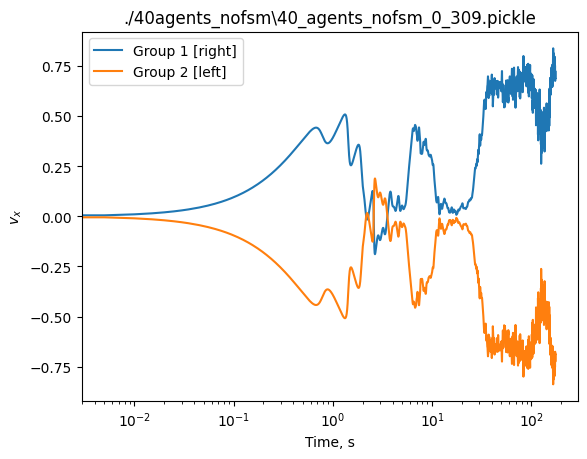

<Figure size 640x480 with 0 Axes>

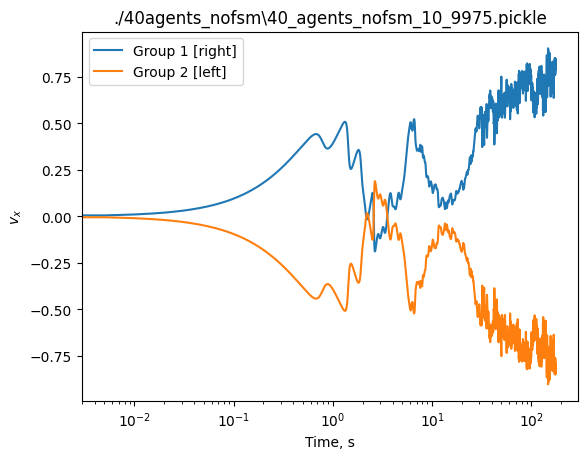

<Figure size 640x480 with 0 Axes>

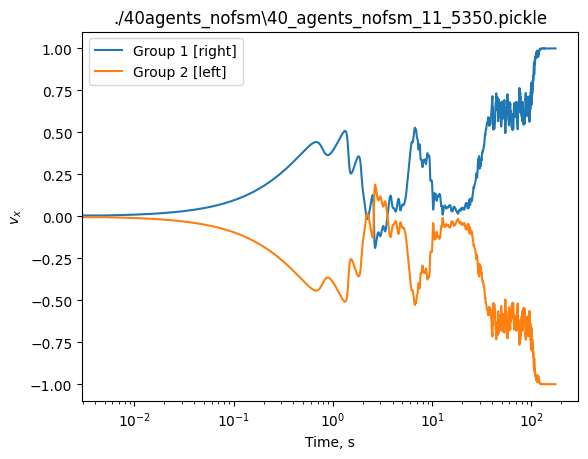

<Figure size 640x480 with 0 Axes>

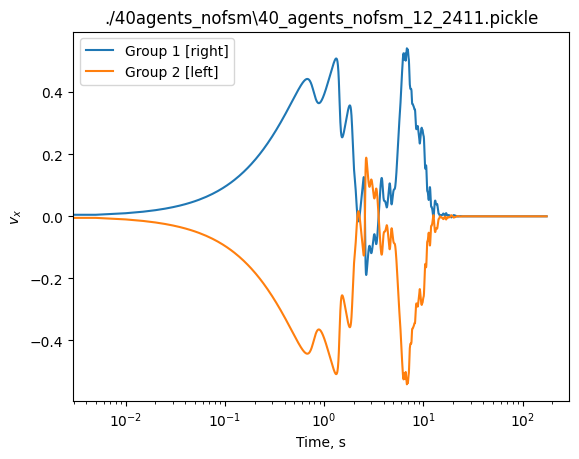

<Figure size 640x480 with 0 Axes>

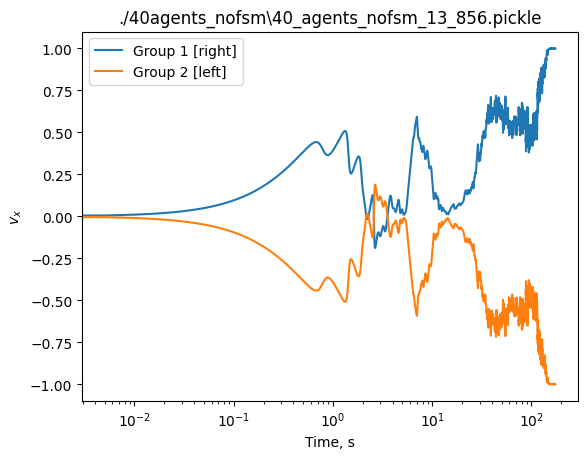

<Figure size 640x480 with 0 Axes>

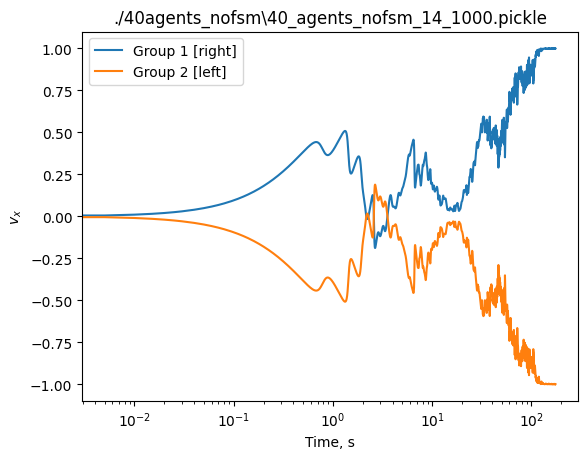

<Figure size 640x480 with 0 Axes>

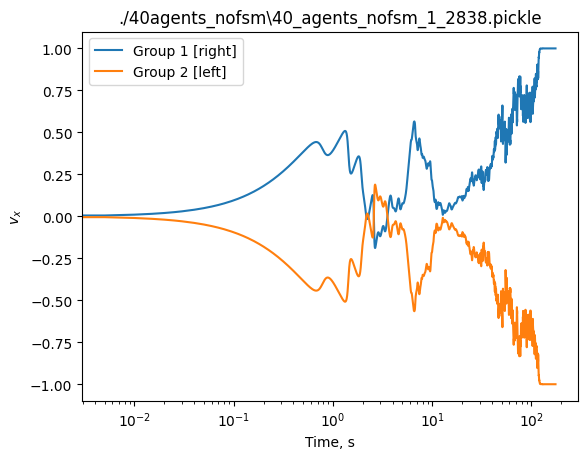

<Figure size 640x480 with 0 Axes>

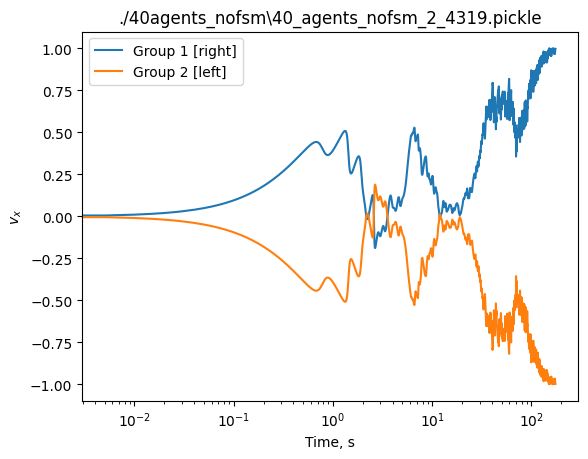

<Figure size 640x480 with 0 Axes>

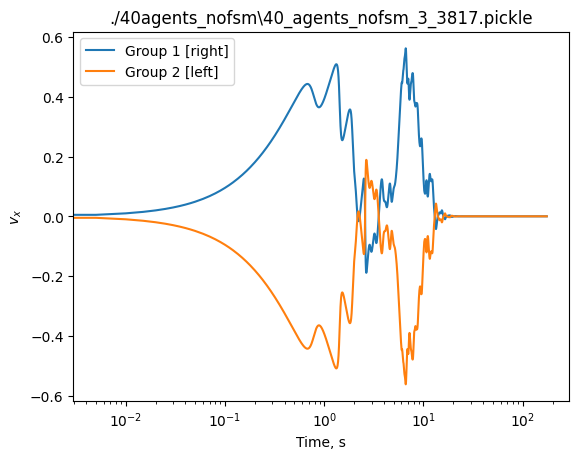

<Figure size 640x480 with 0 Axes>

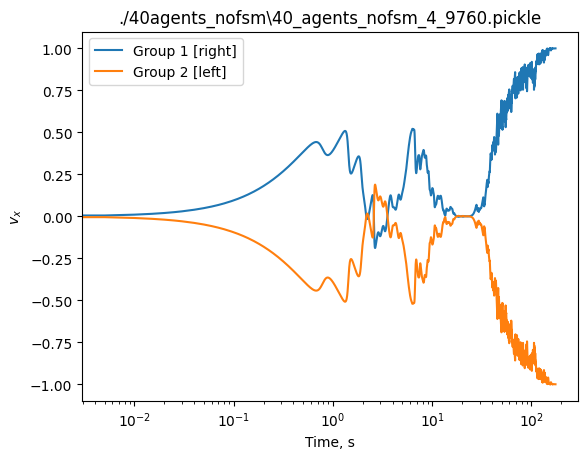

<Figure size 640x480 with 0 Axes>

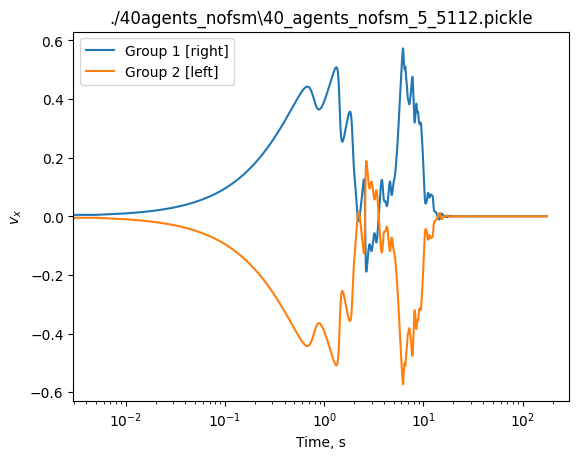

<Figure size 640x480 with 0 Axes>

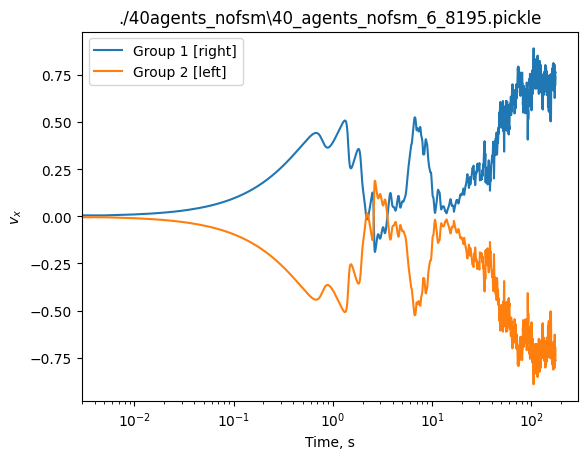

<Figure size 640x480 with 0 Axes>

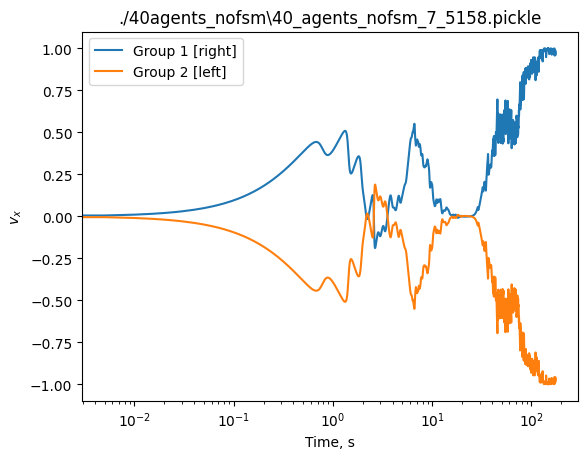

<Figure size 640x480 with 0 Axes>

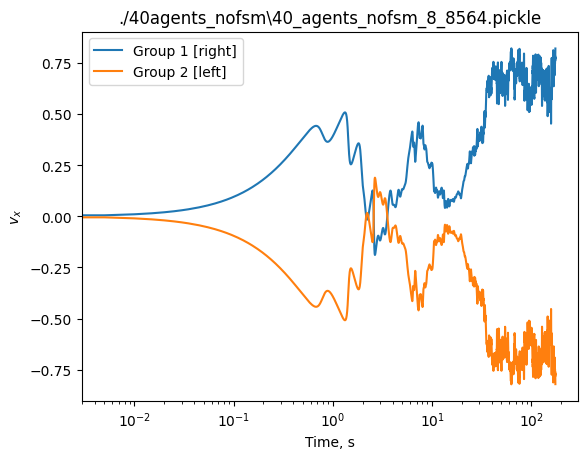

<Figure size 640x480 with 0 Axes>

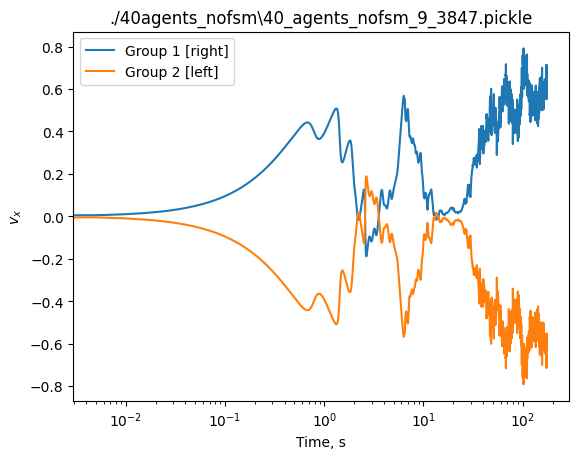

In [78]:

import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype']='none'
from glob import glob
filestart='./40agents_nofsm/*.pickle'
files=glob(filestart)
for file in files:
    with open(file,'rb') as f:
        uData=pickle.load(f)['uData']
    plt.figure()
    print(file)
    
    uData_p = np.array(uData)
    # vData_p = np.array(vData)
    print(uData_p.shape)
    order_g1 = np.mean(uData_p[:, :g1], axis = 1)
    order_g2 = np.mean(uData_p[:, g1:], axis = 1)
    t = np.arange(0, totalTime, deltaT)
    
    
    plt.plot(t, order_g1[:-1], label = 'Group 1 [right]')
    plt.plot(t, order_g2[:-1], label = 'Group 2 [left]')
    # plt.xlim([0, 10])
    plt.title(file)
    # plt.title('Average x-component velocity')
    plt.xlabel('Time, s')
    plt.ylabel(r'$v_{x}$')
    plt.xscale('log')
    # plt.axvline(13)
    plt.legend()